In [15]:
%load_ext autoreload
%autoreload 2

from __future__ import annotations

from dataclasses import replace

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from kuramoto.experiments import evaluate_metric_scores
from kuramoto.analysis import order_parameter
from kuramoto.config import (
    SimulationConfig,
    GridConfig,
    CouplingConfig,
    InitThetaConfig,
    InitOmegaConfig,
    KernelComponentConfig,
    build_simulation,
)
from kuramoto.network import plot_cortical_graph, create_cortical_graph

# -----------------------------------------------------------------------------
# Global notebook knobs
# -----------------------------------------------------------------------------

grid_shape = (12, 12)
T_END = 10.0
dt = 0.01

# Ensemble size per case
N_SEEDS = 5
N_SEEDS_SA1A = 20  # larger ensemble for seed-variance study
BASE_SEED = 42

# Lesion study hyperparameters
n_random_repeats = 10
lesion_fracs = np.arange(0, 0.3, 0.02)
lesion_strength = 1.0

# Quick mode (set True to iterate faster)
QUICK_MODE = True
if QUICK_MODE:
    N_SEEDS = 1
    N_SEEDS_SA1A = 5
    lesion_fracs = np.arange(0, 0.3, 0.05)
    n_random_repeats = 3


# -----------------------------------------------------------------------------
# Case builders
# -----------------------------------------------------------------------------

def bottleneck_group_ids(grid_shape: tuple[int, int]) -> list[int]:
    n_rows, n_cols = grid_shape
    group_ids = np.zeros((n_rows, n_cols), dtype=int)
    group_ids[n_rows // 2 :, :] = 1  # bottom half
    group_ids[n_rows // 2 - 2 : n_rows // 2 + 2, n_cols // 2 - 2 : n_cols // 2 + 2] = 2  # central block
    return group_ids.ravel().tolist()


def random_group_ids(grid_shape: tuple[int, int], n_groups: int, rng: np.random.Generator) -> list[int]:
    n = int(np.prod(grid_shape))
    return rng.integers(0, n_groups, size=n, endpoint=False).astype(int).tolist()

def bottleneck_components_gaussian(k_factor: float = 1.0, seed: int = 42) -> list[KernelComponentConfig]:
    return [
        KernelComponentConfig(
            kernel="gaussian",
            base_strength=1.0*k_factor,
            kernel_params={"sigma": 1.0},
            radius=2.0,
            node_groups=[0],
            edge_mode="within",
        ),
        KernelComponentConfig(
            kernel="gaussian",
            base_strength=1.0*k_factor,
            kernel_params={"sigma": 1.0},
            radius=2.0,
            node_groups=[1],
            edge_mode="within",
        ),
        # bottleneck-like hub (group 2) coupling to/from everyone
        KernelComponentConfig(
            kernel="gaussian",
            base_strength=0.8*k_factor,
            kernel_params={"sigma": 4.0},
            radius=4.0,
            node_groups=[2],
            edge_mode="outgoing",
        ),
        KernelComponentConfig(
            kernel="gaussian",
            base_strength=0.8*k_factor,
            kernel_params={"sigma": 4.0},
            radius=4.0,
            node_groups=[2],
            edge_mode="incoming",
        ),
        # weak one-way coupling from group 1 to group 0
        KernelComponentConfig(
            kernel="gaussian",
            base_strength=0.2*k_factor,
            kernel_params={"sigma": 2.0},
            radius=2.0,
            node_groups=[1],
            edge_mode="custom",
            to_node_groups=[0],
        ),
        # Apply dropout to all groups
        KernelComponentConfig(
        kernel="dropout",
        kernel_params={"dropout_frac": 0.3},
        node_groups=[0,1,2],
        edge_mode="within",
        seed=seed,
        )
    ]

def random_group_components_mixed(n_groups: int = 6, k_factor: float = 1.0, seed: int = 42) -> list[KernelComponentConfig]:
    if n_groups % 2 == 1:
        raise ValueError("n_groups must be even")

    # Size bounds
    SIZE_LB = 0.5
    SIZE_UB = 2.0

    # Size factors
    size_factors = np.random.uniform(SIZE_LB, SIZE_UB, size=n_groups)

    comps: list[KernelComponentConfig] = []
    for g, sf in enumerate(size_factors):
        comps.append(
            KernelComponentConfig(
                kernel="gaussian",
                base_strength=1.0*k_factor,
                kernel_params={"sigma": 1.0*sf},
                radius=3.0*sf,
                node_groups=[g],
                edge_mode="within",
            )
        )

        mh_params = {"sigma_e": 1.0*sf, "sigma_i": 3.0*sf, "a_e": 1.0, "a_i": 0.8}
        comps.append(
            KernelComponentConfig(
                kernel="mexican_hat",
                base_strength=1.0*k_factor,
                kernel_params=mh_params,
                radius=4.0*sf,
                node_groups=[g+n_groups//2],
                edge_mode="within",
            )
        )

    # Apply dropout to all groups
    comps.append(KernelComponentConfig(
        kernel="dropout",
        kernel_params={"dropout_frac": 0.3},
        node_groups=list(range(n_groups)),
        edge_mode="within",
        seed=seed,
    ))

    return comps


def make_case_config(case_name: str, *, seed: int) -> tuple[SimulationConfig, dict]:
    rng = np.random.default_rng(seed)

    init_theta = InitThetaConfig(mode="uniform")
    init_omega = InitOmegaConfig(mode="normal", mu=0.0, sigma=0.3)

    n_groups = 5

    if case_name == "bottleneck_gaussian":
        group_ids = bottleneck_group_ids(grid_shape)
        components = bottleneck_components_gaussian()
        label = "Bottleneck + Gaussian"

    elif case_name == "random_groups_mixed":
        group_ids = random_group_ids(grid_shape, n_groups=n_groups, rng=rng)
        components = random_group_components_mixed(n_groups=n_groups)
        label = "Random-groups(5) + Mixed"

    else:
        raise ValueError(f"Unknown case_name: {case_name!r}")

    cfg = SimulationConfig(
        grid=GridConfig(shape=grid_shape, periodic=False),
        coupling=CouplingConfig(
            kernel="gaussian",
            base_strength=1.0,
            radius=4.0,
            mode="spatial",
            components=components,
            group_ids=group_ids,
        ),
        initial_theta=init_theta,
        initial_omega=init_omega,
        seed=seed,
    )

    meta = {
        "case_name": case_name,
        "case_label": label,
        "seed": seed,
        "n_groups": n_groups,
    }
    return cfg, meta


# -----------------------------------------------------------------------------
# Aggregation utilities
# -----------------------------------------------------------------------------

def list_metrics(results_for_case: dict[int, dict]) -> list[str]:
    any_seed = next(iter(results_for_case.keys()))
    return sorted(results_for_case[any_seed].keys())

def aggregate_scores(results: dict[str, dict[int, dict]]) -> dict:
    out = {}
    for case_name, by_seed in results.items():
        metrics = list_metrics(by_seed)

        out[case_name] = {
            "metrics": metrics,
            "ABC_mean": {},
            "ABC_std": {},
            "AUC_ranked_mean": {},
            "AUC_ranked_std": {},
            "AUC_random_mean": {},
            "AUC_random_std": {},
            "R_avg_ranked_mean": {},
            "R_avg_ranked_std": {},
            "R_avg_random_mean": {},
            "R_avg_random_std": {},
        }

        for m in metrics:
            ABC = np.array([by_seed[s][m]["ABC"] for s in by_seed])
            AUC_r = np.array([by_seed[s][m]["AUC_ranked"] for s in by_seed])
            AUC_rand = np.array([by_seed[s][m]["AUC_random"] for s in by_seed])

            R_ranked = np.array([by_seed[s][m]["R_avg_ranked"] for s in by_seed], dtype=float)
            R_random = np.array([by_seed[s][m]["R_avg_random"] for s in by_seed], dtype=float)

            out[case_name]["ABC_mean"][m] = float(np.mean(ABC))
            out[case_name]["ABC_std"][m] = float(np.std(ABC))

            out[case_name]["AUC_ranked_mean"][m] = float(np.mean(AUC_r))
            out[case_name]["AUC_ranked_std"][m] = float(np.std(AUC_r))

            out[case_name]["AUC_random_mean"][m] = float(np.mean(AUC_rand))
            out[case_name]["AUC_random_std"][m] = float(np.std(AUC_rand))

            out[case_name]["R_avg_ranked_mean"][m] = np.mean(R_ranked, axis=0)
            out[case_name]["R_avg_ranked_std"][m] = np.std(R_ranked, axis=0)

            out[case_name]["R_avg_random_mean"][m] = np.mean(R_random, axis=0)
            out[case_name]["R_avg_random_std"][m] = np.std(R_random, axis=0)

    return out


def rank_correlation_matrix(agg: dict, case_names: list[str]) -> np.ndarray:
    """Pairwise Spearman rho of ABC vectors across conditions."""
    metrics = agg[case_names[0]]["metrics"]
    abc_vecs = np.array([[agg[c]["ABC_mean"][m] for m in metrics] for c in case_names])
    n = len(case_names)
    corr = np.ones((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            rho, _ = spearmanr(abc_vecs[i], abc_vecs[j])
            corr[i, j] = corr[j, i] = rho
    return corr

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 0) Example networks

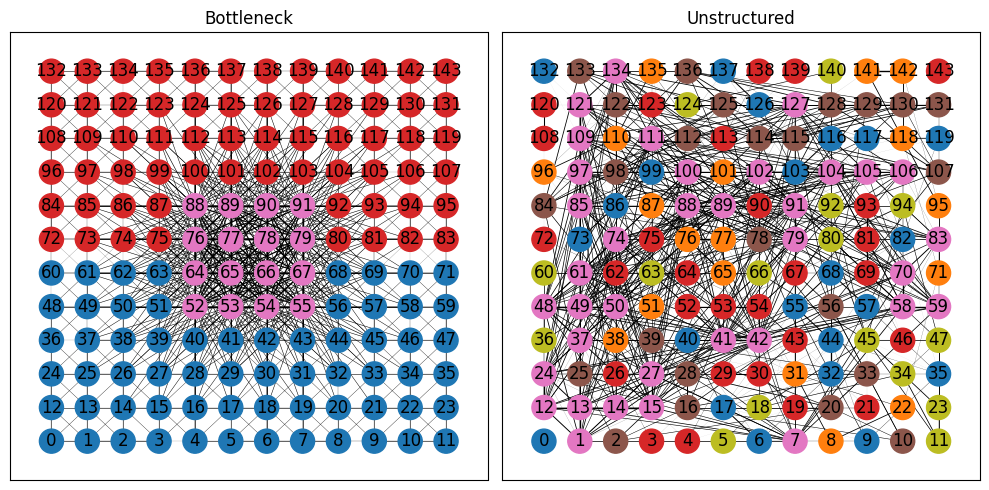

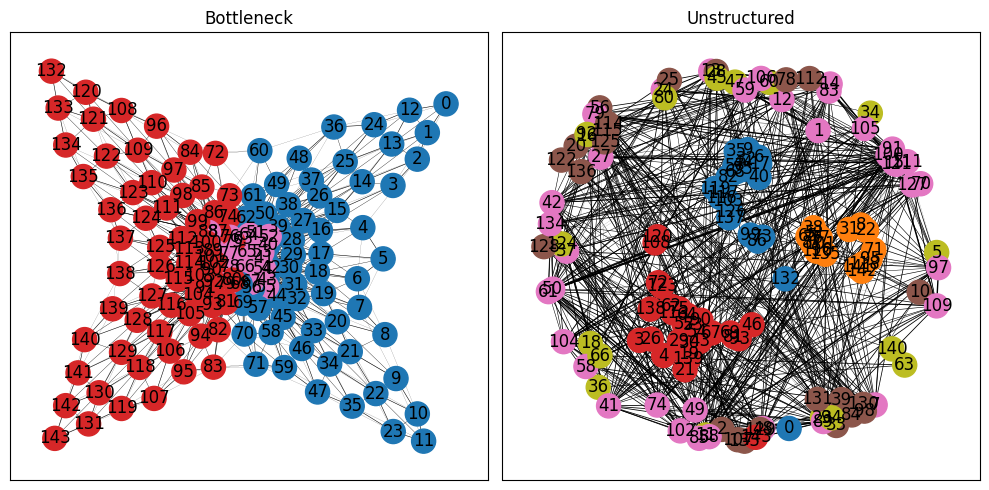

In [17]:
# Bottleneck case
cfg = SimulationConfig(
    grid=GridConfig(shape=grid_shape, periodic=False),
    coupling=CouplingConfig(
        mode="spatial",
        components=bottleneck_components_gaussian(seed=42),
        group_ids=bottleneck_group_ids(grid_shape),
    ),
    initial_theta=InitThetaConfig(mode="uniform"),
    initial_omega=InitOmegaConfig(mode="normal", mu=0.0, sigma=0.3),
    seed=42,
)
sim_bottleneck = build_simulation(config=cfg, rng=np.random.default_rng(42))
G_bottleneck = create_cortical_graph(sim_bottleneck)

# Unstructured case
N_GROUPS = 6
cfg = SimulationConfig(
    grid=GridConfig(shape=grid_shape, periodic=False),
    coupling=CouplingConfig(mode="full", 
                    components=random_group_components_mixed(n_groups=N_GROUPS, seed=42), 
                    group_ids=random_group_ids(grid_shape, n_groups=N_GROUPS, rng=np.random.default_rng(42)),
    ),
    initial_theta=InitThetaConfig(mode="uniform"),
    initial_omega=InitOmegaConfig(mode="normal", mu=0.0, sigma=0.3),
    seed=42,
)
sim_unstructured = build_simulation(config=cfg, rng=np.random.default_rng(42))
G_unstructured = create_cortical_graph(sim_unstructured)

# Show graph structure
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
plot_cortical_graph(G_bottleneck, layout="grid", ax=axs[0])
axs[0].set_title("Bottleneck")
plot_cortical_graph(G_unstructured, layout="grid", ax=axs[1])
axs[1].set_title("Unstructured")
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
plot_cortical_graph(G_bottleneck, layout="spring", ax=axs[0])
axs[0].set_title("Bottleneck")
plot_cortical_graph(G_unstructured, layout="spring", ax=axs[1])
axs[1].set_title("Unstructured")
plt.tight_layout()
plt.show()


### 1a) Seed variance
Quantify how much ABC scores fluctuate from random initialization alone (single IC configuration, many seeds). This determines the ensemble size needed for downstream analyses.

In [18]:
sa1a_seeds = [BASE_SEED + i for i in range(N_SEEDS_SA1A)]

sa1a_results: dict[int, dict] = {}

for seed in sa1a_seeds:
    print(f"SA1a seed={seed}")
    cfg = SimulationConfig(
        grid=GridConfig(shape=grid_shape, periodic=False),
        coupling=CouplingConfig(
            mode="spatial",
            components=bottleneck_components_gaussian(),
            group_ids=bottleneck_group_ids(grid_shape),
        ),
        initial_theta=InitThetaConfig(mode="uniform"),
        initial_omega=InitOmegaConfig(mode="normal", mu=0.0, sigma=0.3),
        seed=seed,
    )
    sim = build_simulation(config=cfg, rng=np.random.default_rng(seed))

    sa1a_results[seed] = evaluate_metric_scores(
        sim, T_END, dt, np.random.default_rng(seed),
        n_random_repeats=n_random_repeats,
        lesion_fracs=lesion_fracs,
        lesion_strength=lesion_strength,
        verbose=False,
    )

print(f"\nDone – {len(sa1a_results)} seeds collected.")

SA1a seed=42
Evaluating deg_base...
Evaluating deg_eff...
Evaluating deg_C_avg...
Evaluating closeness_base...
Evaluating closeness_eff...
Evaluating closeness_C_avg...
Evaluating betweenness_base...
Evaluating betweenness_eff...
Evaluating betweenness_C_avg...
Evaluating eigenvector_base...
Evaluating eigenvector_eff...
Evaluating eigenvector_C_avg...
Evaluating I_final_base...
Evaluating I_final_eff...
Evaluating I_mean_base...
Evaluating I_mean_eff...
Evaluating dRf_dalpha...
Evaluating dRm_dalpha...
SA1a seed=43
Evaluating deg_base...
Evaluating deg_eff...
Evaluating deg_C_avg...
Evaluating closeness_base...
Evaluating closeness_eff...
Evaluating closeness_C_avg...
Evaluating betweenness_base...
Evaluating betweenness_eff...
Evaluating betweenness_C_avg...
Evaluating eigenvector_base...
Evaluating eigenvector_eff...
Evaluating eigenvector_C_avg...
Evaluating I_final_base...
Evaluating I_final_eff...
Evaluating I_mean_base...
Evaluating I_mean_eff...
Evaluating dRf_dalpha...
Evaluat

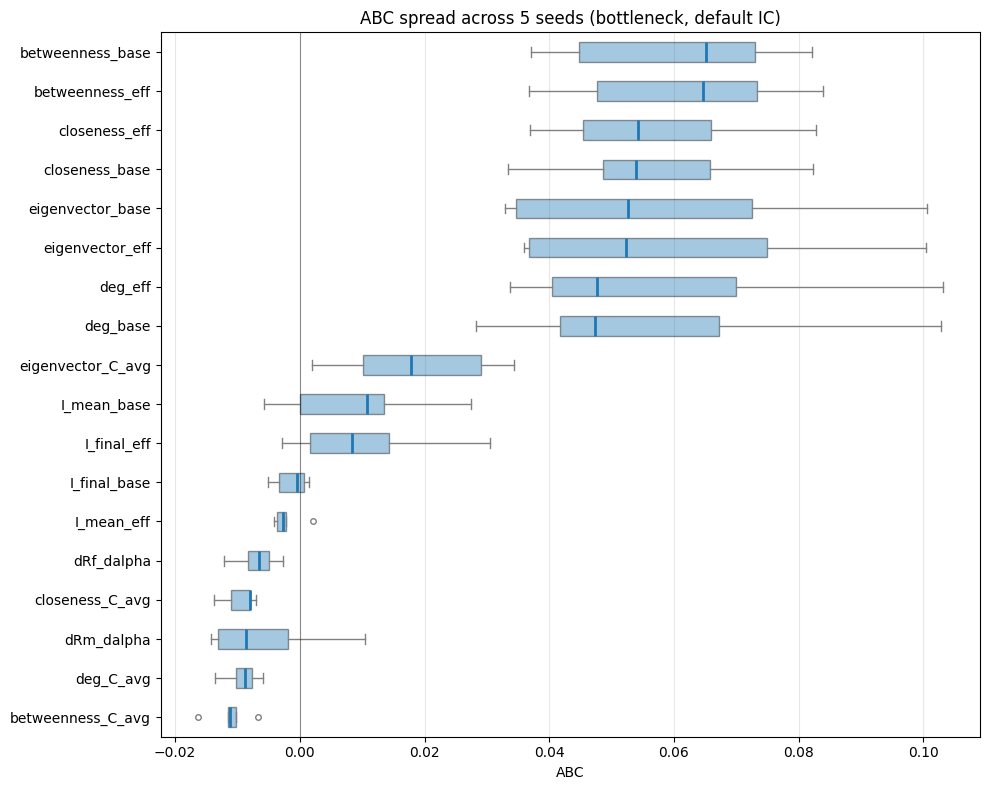

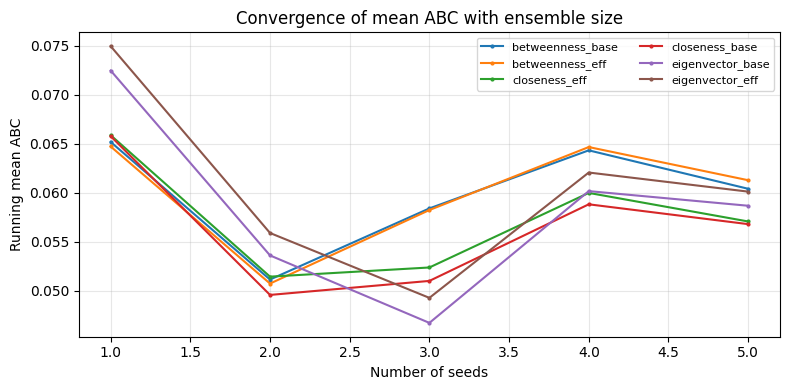

In [19]:
metrics_sa1a = sorted(sa1a_results[sa1a_seeds[0]].keys())
abc_by_metric = {m: [sa1a_results[s][m]["ABC"] for s in sa1a_seeds] for m in metrics_sa1a}

# ── 1) ABC box plot across seeds ──────────────────────────────────────────────
order = sorted(metrics_sa1a, key=lambda m: np.median(abc_by_metric[m]))
data = [abc_by_metric[m] for m in order]

fig, ax = plt.subplots(figsize=(10, max(8, 0.35 * len(order))))
bp = ax.boxplot(
    data, vert=False, patch_artist=True,
    boxprops=dict(facecolor="C0", alpha=0.4),
    medianprops=dict(color="C0", lw=2),
    whiskerprops=dict(color="0.5"),
    capprops=dict(color="0.5"),
    flierprops=dict(marker="o", ms=4, alpha=0.5),
)
ax.set_yticks(range(1, len(order) + 1))
ax.set_yticklabels(order)
ax.set_xlabel("ABC")
ax.set_title(f"ABC spread across {N_SEEDS_SA1A} seeds (bottleneck, default IC)")
ax.axvline(0, color="k", lw=0.8, alpha=0.4)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


# ── 2) Convergence of running mean ABC for top-K metrics ─────────────────────
TOP_K_CONV = 6
top_metrics = sorted(metrics_sa1a, key=lambda m: np.median(abc_by_metric[m]), reverse=True)[:TOP_K_CONV]

fig, ax = plt.subplots(figsize=(8, 4))
for m in top_metrics:
    vals = np.array(abc_by_metric[m])
    running_mean = np.cumsum(vals) / np.arange(1, len(vals) + 1)
    ax.plot(np.arange(1, len(vals) + 1), running_mean, label=m, marker=".", ms=4)

ax.set_xlabel("Number of seeds")
ax.set_ylabel("Running mean ABC")
ax.set_title("Convergence of mean ABC with ensemble size")
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 1b) Distribution sensitivity
With ensemble size justified by 1a, vary the initial-condition *distribution* (omega spread, theta mode) and test whether metric rankings are robust.

In [ ]:
sa1b_omega_sigmas = [0.1, 0.3, 0.5, 1.0]
sa1b_theta_modes = ["uniform", "normal"]
seeds = [BASE_SEED + i for i in range(N_SEEDS)]

sa1b_results: dict[str, dict[int, dict]] = {}
sa1b_base_Rt: dict[str, dict[int, np.ndarray]] = {}
sa1b_labels: dict[str, str] = {}

for omega_sigma in sa1b_omega_sigmas:
    for theta_mode in sa1b_theta_modes:
        case_key = f"theta={theta_mode}_omega_sig={omega_sigma}"
        sa1b_labels[case_key] = f"θ₀={theta_mode}, ωσ={omega_sigma}"
        sa1b_results[case_key] = {}
        sa1b_base_Rt[case_key] = {}

        theta_cfg = InitThetaConfig(mode=theta_mode)
        omega_cfg = InitOmegaConfig(mode="normal", mu=0.0, sigma=omega_sigma)

        for seed in seeds:
            print(f"SA1b  {case_key}  seed={seed}")
            cfg = SimulationConfig(
                grid=GridConfig(shape=grid_shape, periodic=False),
                coupling=CouplingConfig(
                    mode="spatial",
                    components=bottleneck_components_gaussian(),
                    group_ids=bottleneck_group_ids(grid_shape),
                ),
                initial_theta=theta_cfg,
                initial_omega=omega_cfg,
                seed=seed,
            )
            sim = build_simulation(config=cfg, rng=np.random.default_rng(seed))

            res = sim.run((0, T_END), dt)
            Rt, _ = order_parameter(res["theta"])
            sa1b_base_Rt[case_key][seed] = np.asarray(Rt)

            sa1b_results[case_key][seed] = evaluate_metric_scores(
                sim, T_END, dt, np.random.default_rng(seed),
                n_random_repeats=n_random_repeats,
                lesion_fracs=lesion_fracs,
                lesion_strength=lesion_strength,
                verbose=False,
            )

sa1b_agg = aggregate_scores(sa1b_results)
sa1b_case_names = list(sa1b_results.keys())
print(f"\nDone – {len(sa1b_case_names)} conditions × {N_SEEDS} seeds.")

In [ ]:
metrics_sa1b = sa1b_agg[sa1b_case_names[0]]["metrics"]

# ── 1) R(t) sanity traces (one seed per condition) ───────────────────────────
n_theta = len(sa1b_theta_modes)
n_omega = len(sa1b_omega_sigmas)
fig, axs = plt.subplots(n_theta, n_omega, figsize=(4 * n_omega, 3 * n_theta),
                         constrained_layout=True, sharex=True, sharey=True)
for r, theta_mode in enumerate(sa1b_theta_modes):
    for c, omega_sigma in enumerate(sa1b_omega_sigmas):
        case_key = f"theta={theta_mode}_omega_sig={omega_sigma}"
        ax = axs[r, c]
        Rt = sa1b_base_Rt[case_key][seeds[0]]
        ax.plot(np.arange(len(Rt)) * dt, Rt)
        ax.set_ylim(0, 1.05)
        if r == 0:
            ax.set_title(f"ωσ={omega_sigma}")
        if c == 0:
            ax.set_ylabel(f"θ₀={theta_mode}\nR(t)")
        if r == n_theta - 1:
            ax.set_xlabel("t")
plt.suptitle("R(t) sanity check (first seed per condition)")
plt.show()


# ── 2) ABC heatmap: metrics × conditions ─────────────────────────────────────
heat = np.array(
    [[sa1b_agg[c]["ABC_mean"][m] for c in sa1b_case_names] for m in metrics_sa1b],
    dtype=float,
)
fig, ax = plt.subplots(
    figsize=(1.2 * len(sa1b_case_names) + 6, 0.25 * len(metrics_sa1b) + 3),
    constrained_layout=True,
)
im = ax.imshow(heat, aspect="auto", cmap="viridis")
ax.set_xticks(np.arange(len(sa1b_case_names)))
ax.set_xticklabels([sa1b_labels[c] for c in sa1b_case_names], rotation=40, ha="right")
ax.set_yticks(np.arange(len(metrics_sa1b)))
ax.set_yticklabels(metrics_sa1b)
ax.set_title("SA1b: mean ABC across IC distributions")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="ABC")
plt.show()


# ── 3) Top-K metrics per condition ───────────────────────────────────────────
TOP_K = 8
ncols = min(4, len(sa1b_case_names))
nrows_tk = int(np.ceil(len(sa1b_case_names) / ncols))
fig, axs_flat = plt.subplots(
    nrows_tk, ncols, figsize=(5 * ncols, 4 * nrows_tk),
    constrained_layout=True, sharex=False,
)
axs_flat = np.atleast_2d(axs_flat).ravel()
for idx, case_name in enumerate(sa1b_case_names):
    ax = axs_flat[idx]
    items = [(m, sa1b_agg[case_name]["ABC_mean"][m], sa1b_agg[case_name]["ABC_std"][m])
             for m in metrics_sa1b]
    items.sort(key=lambda x: x[1], reverse=True)
    items = items[:TOP_K]
    names = [x[0] for x in items][::-1]
    means = [x[1] for x in items][::-1]
    stds = [x[2] for x in items][::-1]
    ax.barh(names, means, xerr=stds)
    ax.set_title(sa1b_labels[case_name], fontsize=9)
    ax.set_xlabel("ABC")
for idx in range(len(sa1b_case_names), len(axs_flat)):
    axs_flat[idx].set_visible(False)
plt.suptitle(f"Top-{TOP_K} metrics by ABC (mean ± std over {N_SEEDS} seeds)")
plt.show()


# ── 4) Spearman rank-correlation heatmap ─────────────────────────────────────
corr = rank_correlation_matrix(sa1b_agg, sa1b_case_names)
fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ticks = np.arange(len(sa1b_case_names))
ax.set_xticks(ticks)
ax.set_xticklabels([sa1b_labels[c] for c in sa1b_case_names], rotation=45, ha="right", fontsize=8)
ax.set_yticks(ticks)
ax.set_yticklabels([sa1b_labels[c] for c in sa1b_case_names], fontsize=8)
for i in range(len(sa1b_case_names)):
    for j in range(len(sa1b_case_names)):
        ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Spearman ρ")
ax.set_title("SA1b: Rank-correlation of ABC vectors across IC distributions")
plt.show()


# ── 5) Lesion curves for selected metrics ────────────────────────────────────
plot_metrics_sa1b = [
    "deg_base", "betweenness_base", "eigenvector_base",
    "dRf_dalpha", "dRm_dalpha",
]
plot_metrics_sa1b = [m for m in plot_metrics_sa1b if m in metrics_sa1b]

nrows_lc = len(plot_metrics_sa1b)
ncols_lc = len(sa1b_case_names)
fig, axs = plt.subplots(
    nrows_lc, ncols_lc,
    figsize=(3.5 * ncols_lc, 2.6 * nrows_lc),
    constrained_layout=True, sharex=True, sharey=True,
)
if nrows_lc == 1:
    axs = np.expand_dims(axs, axis=0)
if ncols_lc == 1:
    axs = np.expand_dims(axs, axis=1)

for r, metric in enumerate(plot_metrics_sa1b):
    for c, case_name in enumerate(sa1b_case_names):
        ax = axs[r, c]
        x = lesion_fracs
        y = sa1b_agg[case_name]["R_avg_ranked_mean"][metric]
        yerr = sa1b_agg[case_name]["R_avg_ranked_std"][metric]
        ax.plot(x, y, label="ranked", color="tab:blue")
        ax.fill_between(x, y - yerr, y + yerr, color="tab:blue", alpha=0.2)

        y0 = sa1b_agg[case_name]["R_avg_random_mean"][metric]
        y0err = sa1b_agg[case_name]["R_avg_random_std"][metric]
        ax.plot(x, y0, label="random", color="tab:gray")
        ax.fill_between(x, y0 - y0err, y0 + y0err, color="tab:gray", alpha=0.2)

        if r == 0:
            ax.set_title(sa1b_labels[case_name], fontsize=8)
        if c == 0:
            ax.set_ylabel(f"{metric}\nR_avg")
        if r == nrows_lc - 1:
            ax.set_xlabel("lesion_frac")

handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
plt.suptitle("SA1b: Lesion curves across IC distributions")
plt.show()

### 2) Coupling strength sensitivity
Run lesion studies on bottleneck case with varying coupling strength. Compare metric scores across cases.

In [ ]:
sa2_k_factors = [0.25, 0.5, 1.0, 2.0, 4.0]

sa2_results: dict[str, dict[int, dict]] = {}
sa2_base_Rt: dict[str, dict[int, np.ndarray]] = {}
sa2_labels: dict[str, str] = {}

for kf in sa2_k_factors:
    case_key = f"k={kf}"
    sa2_labels[case_key] = f"K×{kf}"
    sa2_results[case_key] = {}
    sa2_base_Rt[case_key] = {}

    for seed in seeds:
        print(f"SA2  {case_key}  seed={seed}")
        cfg = SimulationConfig(
            grid=GridConfig(shape=grid_shape, periodic=False),
            coupling=CouplingConfig(
                mode="spatial",
                components=bottleneck_components_gaussian(k_factor=kf),
                group_ids=bottleneck_group_ids(grid_shape),
            ),
            initial_theta=InitThetaConfig(mode="uniform"),
            initial_omega=InitOmegaConfig(mode="normal", mu=0.0, sigma=0.3),
            seed=seed,
        )
        sim = build_simulation(config=cfg, rng=np.random.default_rng(seed))

        res = sim.run((0, T_END), dt)
        Rt, _ = order_parameter(res["theta"])
        sa2_base_Rt[case_key][seed] = np.asarray(Rt)

        sa2_results[case_key][seed] = evaluate_metric_scores(
            sim, T_END, dt, np.random.default_rng(seed),
            n_random_repeats=n_random_repeats,
            lesion_fracs=lesion_fracs,
            lesion_strength=lesion_strength,
            verbose=False,
        )

sa2_agg = aggregate_scores(sa2_results)
sa2_case_names = list(sa2_results.keys())
print(f"\nDone – {len(sa2_case_names)} k_factors × {N_SEEDS} seeds.")

In [ ]:
metrics_sa2 = sa2_agg[sa2_case_names[0]]["metrics"]

# ── 1) R(t) sanity traces (one seed per k_factor) ────────────────────────────
fig, axs = plt.subplots(1, len(sa2_case_names),
                         figsize=(4 * len(sa2_case_names), 3),
                         constrained_layout=True)
if len(sa2_case_names) == 1:
    axs = [axs]
for ax, case_name in zip(axs, sa2_case_names):
    Rt = sa2_base_Rt[case_name][seeds[0]]
    ax.plot(np.arange(len(Rt)) * dt, Rt)
    ax.set_title(sa2_labels[case_name])
    ax.set_xlabel("t")
    ax.set_ylabel("R(t)")
    ax.set_ylim(0, 1.05)
plt.suptitle("R(t) sanity check (first seed per coupling strength)")
plt.show()


# ── 2) ABC heatmap: metrics × k_factors ──────────────────────────────────────
heat = np.array(
    [[sa2_agg[c]["ABC_mean"][m] for c in sa2_case_names] for m in metrics_sa2],
    dtype=float,
)
fig, ax = plt.subplots(
    figsize=(1.2 * len(sa2_case_names) + 6, 0.25 * len(metrics_sa2) + 3),
    constrained_layout=True,
)
im = ax.imshow(heat, aspect="auto", cmap="viridis")
ax.set_xticks(np.arange(len(sa2_case_names)))
ax.set_xticklabels([sa2_labels[c] for c in sa2_case_names], rotation=30, ha="right")
ax.set_yticks(np.arange(len(metrics_sa2)))
ax.set_yticklabels(metrics_sa2)
ax.set_title("SA2: mean ABC across coupling strengths")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="ABC")
plt.show()


# ── 3) Top-K metrics per k_factor ────────────────────────────────────────────
TOP_K = 8
fig, axs = plt.subplots(1, len(sa2_case_names),
                         figsize=(5 * len(sa2_case_names), 4),
                         constrained_layout=True, sharex=False)
if len(sa2_case_names) == 1:
    axs = [axs]
for ax, case_name in zip(axs, sa2_case_names):
    items = [(m, sa2_agg[case_name]["ABC_mean"][m], sa2_agg[case_name]["ABC_std"][m])
             for m in metrics_sa2]
    items.sort(key=lambda x: x[1], reverse=True)
    items = items[:TOP_K]
    names = [x[0] for x in items][::-1]
    means = [x[1] for x in items][::-1]
    stds = [x[2] for x in items][::-1]
    ax.barh(names, means, xerr=stds)
    ax.set_title(sa2_labels[case_name])
    ax.set_xlabel("ABC")
plt.suptitle(f"SA2: Top-{TOP_K} metrics by ABC (mean ± std over {N_SEEDS} seeds)")
plt.show()


# ── 4) Spearman rank-correlation heatmap ─────────────────────────────────────
corr = rank_correlation_matrix(sa2_agg, sa2_case_names)
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ticks = np.arange(len(sa2_case_names))
ax.set_xticks(ticks)
ax.set_xticklabels([sa2_labels[c] for c in sa2_case_names], rotation=30, ha="right")
ax.set_yticks(ticks)
ax.set_yticklabels([sa2_labels[c] for c in sa2_case_names])
for i in range(len(sa2_case_names)):
    for j in range(len(sa2_case_names)):
        ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Spearman ρ")
ax.set_title("SA2: Rank-correlation of ABC vectors across coupling strengths")
plt.show()


# ── 5) Lesion curves for selected metrics ────────────────────────────────────
plot_metrics_sa2 = [
    "deg_base", "betweenness_base", "eigenvector_base",
    "dRf_dalpha", "dRm_dalpha",
]
plot_metrics_sa2 = [m for m in plot_metrics_sa2 if m in metrics_sa2]

nrows_lc = len(plot_metrics_sa2)
ncols_lc = len(sa2_case_names)
fig, axs = plt.subplots(
    nrows_lc, ncols_lc,
    figsize=(3.5 * ncols_lc, 2.6 * nrows_lc),
    constrained_layout=True, sharex=True, sharey=True,
)
if nrows_lc == 1:
    axs = np.expand_dims(axs, axis=0)
if ncols_lc == 1:
    axs = np.expand_dims(axs, axis=1)

for r, metric in enumerate(plot_metrics_sa2):
    for c, case_name in enumerate(sa2_case_names):
        ax = axs[r, c]
        x = lesion_fracs
        y = sa2_agg[case_name]["R_avg_ranked_mean"][metric]
        yerr = sa2_agg[case_name]["R_avg_ranked_std"][metric]
        ax.plot(x, y, label="ranked", color="tab:blue")
        ax.fill_between(x, y - yerr, y + yerr, color="tab:blue", alpha=0.2)

        y0 = sa2_agg[case_name]["R_avg_random_mean"][metric]
        y0err = sa2_agg[case_name]["R_avg_random_std"][metric]
        ax.plot(x, y0, label="random", color="tab:gray")
        ax.fill_between(x, y0 - y0err, y0 + y0err, color="tab:gray", alpha=0.2)

        if r == 0:
            ax.set_title(sa2_labels[case_name])
        if c == 0:
            ax.set_ylabel(f"{metric}\nR_avg")
        if r == nrows_lc - 1:
            ax.set_xlabel("lesion_frac")

handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
plt.suptitle("SA2: Lesion curves across coupling strengths")
plt.show()

### 3) Structural sensitivity
Compare bottleneck and unstructured network.

In [ ]:
# -----------------------------------------------------------------------------
# Plots
# -----------------------------------------------------------------------------

# 1) R(t) sanity checks (one representative seed per case)
fig, axs = plt.subplots(1, len(case_names), figsize=(4 * len(case_names), 3), constrained_layout=True)
for ax, case_name in zip(axs, case_names):
    seed0 = seeds[0]
    Rt = base_Rt[case_name][seed0]
    ax.plot(np.arange(Rt.shape[0]) * dt, Rt)
    ax.set_title(case_labels[case_name])
    ax.set_xlabel("t")
    ax.set_ylabel("R(t)")
    ax.set_ylim(0, 1.05)
plt.show()


# 2) ABC heatmap: metrics x cases
metrics = agg[case_names[0]]["metrics"]
heat = np.array([[agg[c]["ABC_mean"][m] for c in case_names] for m in metrics], dtype=float)

fig, ax = plt.subplots(figsize=(1.2 * len(case_names) + 6, 0.25 * len(metrics) + 3), constrained_layout=True)
im = ax.imshow(heat, aspect="auto", cmap="viridis")
ax.set_xticks(np.arange(len(case_names)))
ax.set_xticklabels([case_labels[c] for c in case_names], rotation=30, ha="right")
ax.set_yticks(np.arange(len(metrics)))
ax.set_yticklabels(metrics)
ax.set_title("Metric lesion-score by case (mean ABC; higher = better-than-random separation)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="ABC (AUC_random - AUC_ranked)")
plt.show()


# 3) Top-k metrics per case (by mean ABC)
TOP_K = 8
fig, axs = plt.subplots(1, len(case_names), figsize=(4 * len(case_names), 4), constrained_layout=True, sharex=False)
for ax, case_name in zip(axs, case_names):
    items = [(m, agg[case_name]["ABC_mean"][m], agg[case_name]["ABC_std"][m]) for m in metrics]
    items.sort(key=lambda x: x[1], reverse=True)
    items = items[:TOP_K]

    names = [x[0] for x in items][::-1]
    means = [x[1] for x in items][::-1]
    stds = [x[2] for x in items][::-1]

    ax.barh(names, means, xerr=stds)
    ax.set_title(case_labels[case_name])
    ax.set_xlabel("ABC")

plt.suptitle(f"Top-{TOP_K} metrics by ABC (mean ± std over {N_SEEDS} seeds)")
plt.show()


# 4) Lesion curves (small multiples) for a shortlist of metrics
plot_metrics = [
    "deg_base",
    "betweenness_base",
    "eigenvector_base",
    "dRf_dalpha",
    "dRm_dalpha",
]
plot_metrics = [m for m in plot_metrics if m in metrics]

nrows = len(plot_metrics)
fig, axs = plt.subplots(nrows, len(case_names), figsize=(4 * len(case_names), 2.6 * nrows), constrained_layout=True, sharex=True, sharey=True)
if nrows == 1:
    axs = np.expand_dims(axs, axis=0)

for r, metric in enumerate(plot_metrics):
    for c, case_name in enumerate(case_names):
        ax = axs[r, c]
        x = lesion_fracs

        y = agg[case_name]["R_avg_ranked_mean"][metric]
        yerr = agg[case_name]["R_avg_ranked_std"][metric]
        ax.plot(x, y, label="ranked", color="tab:blue")
        ax.fill_between(x, y - yerr, y + yerr, color="tab:blue", alpha=0.2)

        y0 = agg[case_name]["R_avg_random_mean"][metric]
        y0err = agg[case_name]["R_avg_random_std"][metric]
        ax.plot(x, y0, label="random", color="tab:gray")
        ax.fill_between(x, y0 - y0err, y0 + y0err, color="tab:gray", alpha=0.2)

        if r == 0:
            ax.set_title(case_labels[case_name])
        if c == 0:
            ax.set_ylabel(f"{metric}\nR_avg")
        if r == nrows - 1:
            ax.set_xlabel("lesion_frac")

handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
plt.suptitle("Lesion curves: mean ± std across seeds")
plt.show()